# Eksperimen Local Search — Penjadwalan Mata Kuliah

Notebook ini menjalankan seluruh eksperimen yang mendukung **Spesifikasi Local Search**
pada Task #2 Seleksi Laboratorium Inteligensi Buatan.

Isi:

1. Definisi instansi masalah dan ukuran ruang pencarian
2. Initial state random dan rincian objective function
3. Enam algoritma dijalankan dari state awal yang sama
4. Grafik nilai objective terhadap iterasi
5. Diagnostik Simulated Annealing dan Genetic Algorithm
6. Eksperimen multi-seed (10 seed) untuk melihat kestabilan tiap algoritma
7. Sensitivitas hyperparameter SA dan GA

> Jalankan notebook ini dari direktori `notebooks/local_search/`.

In [1]:
import sys, random, time, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SRC = Path.cwd().parents[1] / "src"
sys.path.insert(0, str(SRC))

from local_search import algorithms as algo
from local_search import visualize as viz
from local_search.problem import default_problem, slot_name

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("sumber:", SRC)

sumber: C:\Users\Naufal\OneDrive\Documents\Asisten\AI_contoh\Task2_AI_13524012\src


## 1. Instansi masalah

Instansi bawaan meniru satu semester di STEI ITB: 36 kelas mata kuliah, 11 ruangan
(8 ruang kuliah + 3 laboratorium), 10 dosen, 8 kelompok mahasiswa, dan 25 slot waktu
(5 hari x 5 sesi dua jam).

In [2]:
problem = default_problem()
print("Instansi          :", problem.name)
print("Mata kuliah (n)   :", problem.n)
print("Ruangan (|R|)     :", problem.n_rooms)
print("Slot waktu (|T|)  :", problem.n_slots)
print("Ukuran ruang state: (25 x 11)^36 = %.3e" % ((problem.n_slots * problem.n_rooms) ** problem.n))
print("Neighborhood      :", problem.neighborhood_size(), "state per iterasi")
print()
print("Ruangan:")
for r in problem.rooms:
    print(f"  {r.name:<12} kapasitas={r.capacity:>4}  jenis={r.kind}")

Instansi          : STEI-ITB (36 kelas / 11 ruang / 25 slot)
Mata kuliah (n)   : 36
Ruangan (|R|)     : 11
Slot waktu (|T|)  : 25
Ukuran ruang state: (25 x 11)^36 = 6.546e+87
Neighborhood      : 1854 state per iterasi

Ruangan:
  7502         kapasitas= 120  jenis=KULIAH
  7602         kapasitas= 100  jenis=KULIAH
  7603         kapasitas= 100  jenis=KULIAH
  9009         kapasitas=  80  jenis=KULIAH
  9010         kapasitas=  80  jenis=KULIAH
  7610         kapasitas=  60  jenis=KULIAH
  7611         kapasitas=  60  jenis=KULIAH
  7612         kapasitas=  40  jenis=KULIAH
  Lab-Dasar    kapasitas=  60  jenis=LAB
  Lab-IRK      kapasitas=  40  jenis=LAB
  Lab-Grafika  kapasitas=  40  jenis=LAB


In [3]:
import pandas as pd
pd.DataFrame([{
    "kode": c.code, "nama": c.name, "dosen": problem.lecturers[c.lecturer],
    "kelompok": ", ".join(problem.groups[g] for g in c.groups),
    "mahasiswa": c.students, "butuh_lab": c.needs_lab,
} for c in problem.courses])

,kode,nama,dosen,kelompok,mahasiswa,butuh_lab
0,IF2110,Algoritma dan Struktur Data,Dr. Adiwijaya,"IF-24-K01, IF-24-K02",96,False
1,IF2110-P,Praktikum Algoritma dan Struktur Data,Dr. Adiwijaya,IF-24-K01,48,True
2,IF2120,Matematika Diskrit,Dr. Bagus Priambodo,"IF-24-K01, IF-24-K02",96,False
3,IF2123,Aljabar Linier dan Geometri,Dr. Bagus Priambodo,"IF-24-K01, IF-24-K02",92,False
4,IF2124,Teori Bahasa Formal dan Otomata,Dr. Citra Handayani,"IF-24-K01, IF-24-K02",90,False
5,IF2130,Organisasi dan Arsitektur Komputer,Dr. Dimas Kurniawan,"IF-24-K01, IF-24-K02",88,False
6,IF2130-P,Praktikum Organisasi Komputer,Dr. Dimas Kurniawan,IF-24-K02,44,True
7,IF2211,Strategi Algoritma,Dr. Citra Handayani,"IF-23-K01, IF-23-K02",94,False
8,IF2211-P,Praktikum Strategi Algoritma,Dr. Citra Handayani,IF-23-K01,47,True
9,IF2210,Pemrograman Berorientasi Objek,Dr. Elvira Setiawan,"IF-23-K01, IF-23-K02",94,False


## 2. Initial state random dan objective function

State awal dibangkitkan dengan mengundi pasangan `(slot, ruang)` secara seragam untuk
setiap mata kuliah — tanpa perbaikan apa pun. Karena itu ia hampir selalu melanggar
banyak *hard constraint*.

In [4]:
SEED = 42
rng = random.Random(SEED)
initial = problem.random_state(rng)
init_cost = problem.evaluate(initial)
print(init_cost.report())

Objective f(X) = 2015
  Hard constraints (bobot besar):
    room_clash                1 x 100  =    100
    lecturer_clash            0 x 100  =      0
    group_clash               4 x 100  =    400
    capacity                 13 x 60   =    780
    room_type                 6 x 80   =    480
  Soft constraints:
    lecturer_unavailable     10 x 10   =    100
    late_slot                 6 x 3    =     18
    lecturer_overload         1 x 5    =      5
    group_overload            3 x 4    =     12
    group_gap                 7 x 2    =     14
    lecturer_gap              8 x 2    =     16
    room_waste               66 x 1    =     66
    lab_misuse                6 x 4    =     24
  -> total pelanggaran keras = 24 (TIDAK FEASIBLE), penalti lunak = 255


In [5]:
print(viz.render_timetable(problem, initial))

Jam          Senin                 Selasa                Rabu                  Kamis                 Jumat                 
---------------------------------------------------------------------------------------------------------------------------
07.00-09.00  IF2110-P@9010         -                     IF3170@9010           -                     IF2110@7602
             IF2211@7602           -                     -                     -                     EL2140@Lab-IRK
             IF2210-P@Lab-Dasar    -                     -                     -                     -

09.00-11.00  STI2130@7612          IF2211-P@9009         STI2110@7610          IF2210@Lab-IRK        IF2124@Lab-Dasar
             EL3140@Lab-Grafika    IF2220@Lab-Grafika    EL2140-P@Lab-IRK      -                     -
             -                     EL2240@7602           -                     -                     -

11.00-13.00  IF2130@Lab-IRK        IF2120@9009           IF3260@7602           STI2210@7602   

## 3. Menjalankan keenam algoritma dari state awal yang sama

In [6]:
results = {}
for i, key in enumerate(algo.ALGORITHMS):
    sub_rng = random.Random(SEED + 1000 * (i + 1))
    t0 = time.perf_counter()
    if key == "hc-steepest":
        res = algo.hill_climbing_steepest(problem, initial)
    elif key == "hc-sideways":
        res = algo.hill_climbing_sideways(problem, initial, max_sideways=40, rng=sub_rng)
    elif key == "hc-stochastic":
        res = algo.hill_climbing_stochastic(problem, initial, max_iter=30000, rng=sub_rng)
    elif key == "hc-random-restart":
        res = algo.hill_climbing_random_restart(problem, restarts=5, rng=sub_rng, initial=initial)
    elif key == "sa":
        res = algo.simulated_annealing(problem, initial, t0_temp=60.0, alpha=0.9997,
                                       max_iter=60000, rng=sub_rng)
    else:
        res = algo.genetic_algorithm(problem, population_size=80, generations=400,
                                     mutation_rate=0.2, rng=sub_rng, initial=initial)
    results[key] = res
    print(res.summary())
    print()

[Hill-Climbing (Steepest-Ascent)]
  objective awal   : 2015
  objective akhir  : 18  (FEASIBLE)
  perbaikan        : 1997
  iterasi          : 41
  evaluasi f(X)    : 77866
  durasi           : 3.570 s
  berhenti_karena  : local optimum



[Hill-Climbing (Sideways Move)]
  objective awal   : 2015
  objective akhir  : 16  (FEASIBLE)
  perbaikan        : 1999
  iterasi          : 83
  evaluasi f(X)    : 155734
  durasi           : 7.068 s
  sideways_terpakai: 40
  batas_sideways   : 40



[Hill-Climbing (Stochastic)]
  objective awal   : 2015
  objective akhir  : 75  (tidak feasible, 1 pelanggaran keras)
  perbaikan        : 1940
  iterasi          : 30000
  evaluasi f(X)    : 30001
  durasi           : 1.457 s
  move_diterima    : 89
  rasio_penerimaan : 0.003



[Hill-Climbing (Random Restart, 5x)]
  objective awal   : 2015
  objective akhir  : 16  (FEASIBLE)
  perbaikan        : 1999
  iterasi          : 216
  evaluasi f(X)    : 409728
  durasi           : 18.374 s
  jumlah_restart   : 5
  objective_per_restart: [18, 16, 18, 77, 75]
  restart_terbaik  : 2
  iterasi_per_restart: 43.2



[Simulated Annealing]
  objective awal   : 2015
  objective akhir  : 16  (FEASIBLE)
  perbaikan        : 1999
  iterasi          : 36669
  evaluasi f(X)    : 36670
  durasi           : 1.760 s
  T0               : 60.0
  alpha            : 0.9997
  T_akhir          : 0.001
  move_memburuk_diterima: 1493
  move_memburuk_ditolak: 30578
  stuck_di_suhu_rendah: 21062



[Genetic Algorithm]
  objective awal   : 2015
  objective akhir  : 31  (FEASIBLE)
  perbaikan        : 1984
  iterasi          : 400
  evaluasi f(X)    : 32080
  durasi           : 1.507 s
  ukuran_populasi  : 80
  generasi         : 400
  crossover        : uniform
  crossover_rate   : 0.9
  mutation_rate    : 0.2
  elitism          : 2
  tournament_k     : 3



In [7]:
pd.DataFrame([{
    "algoritma": r.name,
    "f(awal)": r.initial_cost.total,
    "f(akhir)": r.final_cost.total,
    "pelanggaran keras": r.final_cost.hard_violations,
    "penalti lunak": r.final_cost.soft_penalty,
    "iterasi": r.iterations,
    "evaluasi f(X)": r.evaluations,
    "detik": round(r.duration, 2),
} for r in results.values()]).sort_values("f(akhir)").reset_index(drop=True)

,algoritma,f(awal),f(akhir),pelanggaran keras,penalti lunak,iterasi,evaluasi f(X),detik
0,Hill-Climbing (Sideways Move),2015,16,0,16,83,155734,7.07
1,"Hill-Climbing (Random Restart, 5x)",2015,16,0,16,216,409728,18.37
2,Simulated Annealing,2015,16,0,16,36669,36670,1.76
3,Hill-Climbing (Steepest-Ascent),2015,18,0,18,41,77866,3.57
4,Genetic Algorithm,2015,31,0,31,400,32080,1.51
5,Hill-Climbing (Stochastic),2015,75,1,15,30000,30001,1.46


## 4. Nilai objective function terhadap iterasi

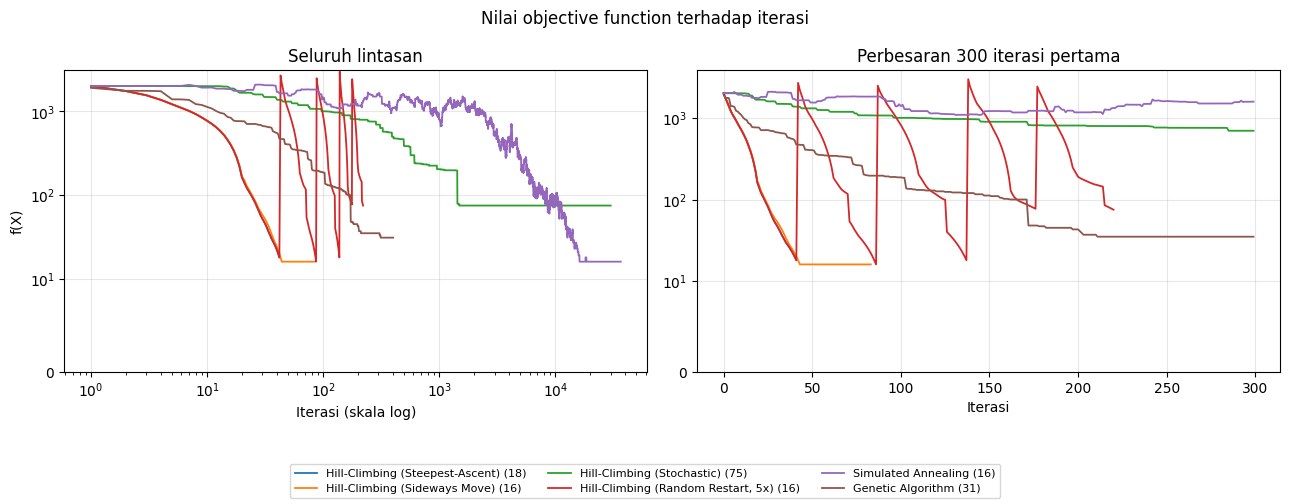

In [8]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for r in results.values():
    ax.plot(range(1, len(r.history) + 1), r.history, lw=1.3,
            label=f"{r.name} ({r.final_cost.total})")
    ax2.plot(r.history[:300], lw=1.3)
ax.set_xscale("log"); ax.set_xlabel("Iterasi (skala log)"); ax.set_ylabel("f(X)")
ax2.set_xlabel("Iterasi"); ax2.set_title("Perbesaran 300 iterasi pertama")
for a in (ax, ax2):
    a.set_yscale("symlog", linthresh=10); a.set_ylim(bottom=0)
ax.set_title("Seluruh lintasan")
fig.legend(*ax.get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=8)
fig.suptitle("Nilai objective function terhadap iterasi")
fig.tight_layout(rect=(0, 0.13, 1, 1))
plt.show()

## 5. Diagnostik Simulated Annealing

Panel bawah menunjukkan peluang penerimaan $e^{-\Delta E/T}$ untuk setiap *move* yang
memperburuk objective. Peluang ini mendekati 1 saat suhu masih tinggi lalu meluruh ke 0
— inilah mekanisme yang membuat SA mampu keluar dari local optimum di awal pencarian
dan berperilaku seperti Hill-Climbing di akhir.

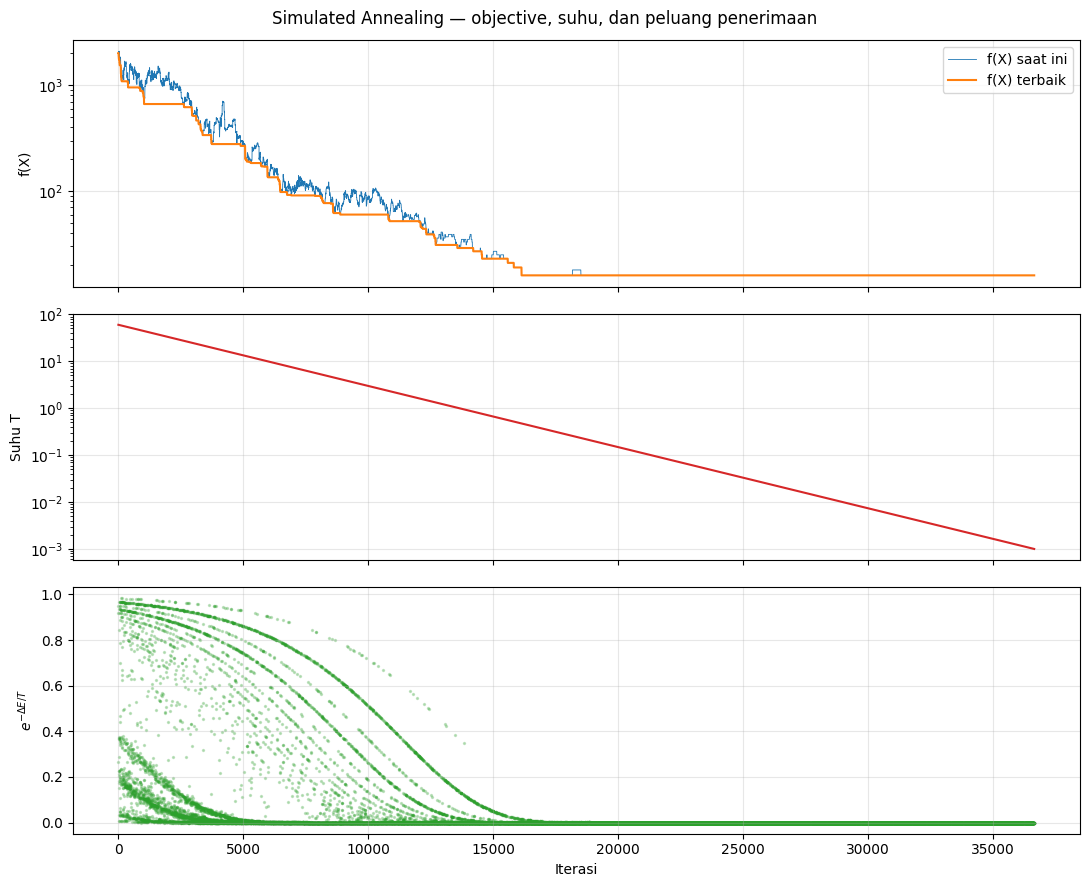

move memburuk diterima : 1493
move memburuk ditolak  : 30578
ditolak saat T < 1     : 21062


In [9]:
sa = results["sa"]
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(sa.history, lw=0.6, label="f(X) saat ini")
axes[0].plot(sa.extras["best_history"], lw=1.5, label="f(X) terbaik")
axes[0].set_yscale("log"); axes[0].set_ylabel("f(X)"); axes[0].legend()
axes[1].plot(sa.extras["temperatures"], color="tab:red")
axes[1].set_yscale("log"); axes[1].set_ylabel("Suhu T")
pr = sa.extras["accept_probs"]
axes[2].scatter([p[0] for p in pr], [p[1] for p in pr], s=2, alpha=0.25, color="tab:green")
axes[2].set_ylabel(r"$e^{-\Delta E/T}$"); axes[2].set_xlabel("Iterasi")
fig.suptitle("Simulated Annealing — objective, suhu, dan peluang penerimaan")
fig.tight_layout(); plt.show()

print("move memburuk diterima :", sa.extras["move_memburuk_diterima"])
print("move memburuk ditolak  :", sa.extras["move_memburuk_ditolak"])
print("ditolak saat T < 1     :", sa.extras["stuck_di_suhu_rendah"])

## 6. Diagnostik Genetic Algorithm

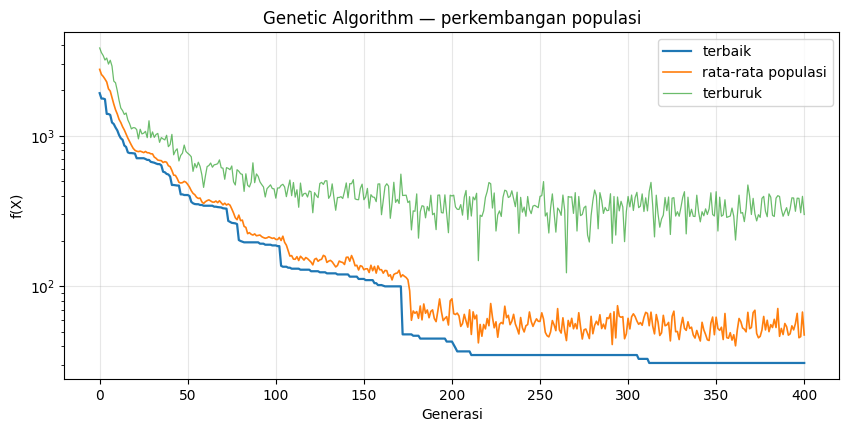

In [10]:
ga = results["ga"]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ga.history, lw=1.6, label="terbaik")
ax.plot(ga.extras["avg_history"], lw=1.2, label="rata-rata populasi")
ax.plot(ga.extras["worst_history"], lw=0.9, alpha=0.7, label="terburuk")
ax.set_yscale("log"); ax.set_xlabel("Generasi"); ax.set_ylabel("f(X)")
ax.set_title("Genetic Algorithm — perkembangan populasi"); ax.legend()
plt.show()

## 7. Eksperimen multi-seed

Satu kali jalan tidak cukup untuk menyimpulkan algoritma mana yang lebih baik: baik
state awal maupun keputusan internal beberapa algoritma bersifat acak. Di sini keenam
algoritma dijalankan pada **10 state awal berbeda**.

In [11]:
SEEDS = list(range(1, 11))
rows = []
for s in SEEDS:
    r0 = random.Random(s)
    x0 = problem.random_state(r0)
    f0 = problem.objective(x0)
    runs = {
        "HC steepest":    algo.hill_climbing_steepest(problem, x0),
        "HC sideways":    algo.hill_climbing_sideways(problem, x0, max_sideways=40, rng=random.Random(s + 100)),
        "HC stochastic":  algo.hill_climbing_stochastic(problem, x0, max_iter=30000, rng=random.Random(s + 200)),
        "HC restart(5x)": algo.hill_climbing_random_restart(problem, restarts=5, rng=random.Random(s + 300), initial=x0),
        "SA":             algo.simulated_annealing(problem, x0, t0_temp=60.0, alpha=0.9997, max_iter=60000, rng=random.Random(s + 400)),
        "GA":             algo.genetic_algorithm(problem, population_size=80, generations=400, mutation_rate=0.2, rng=random.Random(s + 500), initial=x0),
    }
    for name, r in runs.items():
        rows.append({"seed": s, "algoritma": name, "f_awal": f0,
                     "f_akhir": r.final_cost.total,
                     "feasible": r.final_cost.feasible,
                     "detik": r.duration})
multi = pd.DataFrame(rows)
multi.head(12)

,seed,algoritma,f_awal,f_akhir,feasible,detik
0,1,HC steepest,2813,18,True,3.977790
1,1,HC sideways,2813,16,True,7.399815
2,1,HC stochastic,2813,16,True,1.353151
3,1,HC restart(5x),2813,16,True,19.526057
4,1,SA,2813,16,True,1.726194
5,1,GA,2813,20,True,1.542853
6,2,HC steepest,2579,16,True,3.849576
7,2,HC sideways,2579,16,True,8.995241
8,2,HC stochastic,2579,134,False,1.388141
9,2,HC restart(5x),2579,16,True,18.556290


In [12]:
ringkas = multi.groupby("algoritma").agg(
    f_akhir_rata2=("f_akhir", "mean"),
    f_akhir_std=("f_akhir", "std"),
    f_akhir_min=("f_akhir", "min"),
    f_akhir_maks=("f_akhir", "max"),
    persen_feasible=("feasible", "mean"),
    detik_rata2=("detik", "mean"),
).sort_values("f_akhir_rata2")
ringkas["persen_feasible"] = (ringkas["persen_feasible"] * 100).round(0)
ringkas.round(2)

,f_akhir_rata2,f_akhir_std,f_akhir_min,f_akhir_maks,persen_feasible,detik_rata2
algoritma,,,,,,
HC sideways,16.0,0.00,16,16,100.0,7.68
SA,16.0,0.00,16,16,100.0,1.74
HC restart(5x),16.2,0.63,16,18,100.0,18.82
GA,21.0,3.30,16,27,100.0,1.55
HC steepest,45.7,41.57,16,134,60.0,3.81
HC stochastic,64.2,46.84,16,136,40.0,1.38


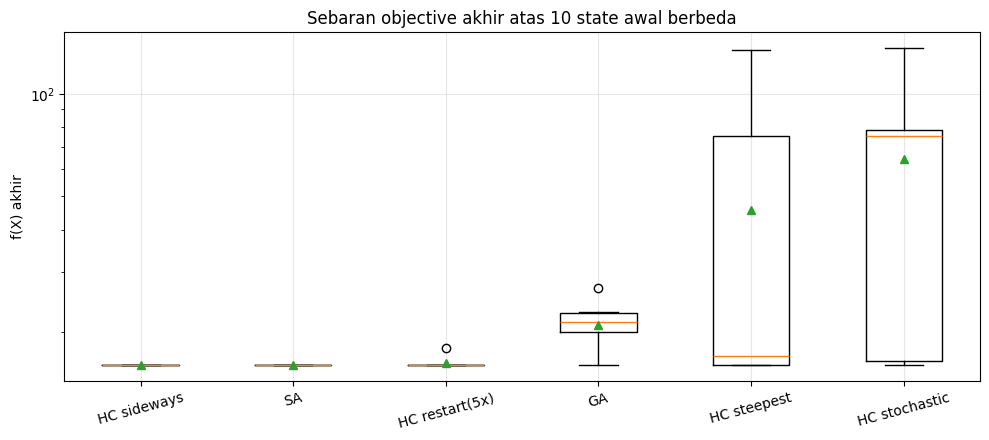

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = ringkas.index.tolist()
data = [multi.loc[multi.algoritma == a, "f_akhir"].values for a in order]
ax.boxplot(data, tick_labels=order, showmeans=True)
ax.set_ylabel("f(X) akhir"); ax.set_yscale("log")
ax.set_title("Sebaran objective akhir atas 10 state awal berbeda")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 8. Sensitivitas hyperparameter

### 8.1 Simulated Annealing — laju pendinginan

In [14]:
rows = []
for alpha in [0.999, 0.9995, 0.9997, 0.9999]:
    for T0 in [20.0, 60.0, 150.0]:
        vals = []
        for s in range(1, 6):
            x0 = problem.random_state(random.Random(s))
            r = algo.simulated_annealing(problem, x0, t0_temp=T0, alpha=alpha,
                                         max_iter=60000, rng=random.Random(s + 900))
            vals.append(r.final_cost.total)
        rows.append({"alpha": alpha, "T0": T0,
                     "f_rata2": np.mean(vals), "f_min": np.min(vals)})
sa_grid = pd.DataFrame(rows)
sa_grid.pivot(index="alpha", columns="T0", values="f_rata2").round(1)

T0,20.0,60.0,150.0
alpha,,,
0.9990,16.0,16.4,16.0
0.9995,16.0,16.0,16.0
0.9997,16.0,16.0,16.0
0.9999,16.0,16.0,16.0


### 8.2 Genetic Algorithm — ukuran populasi dan peluang mutasi

In [15]:
rows = []
for pop in [30, 80, 160]:
    for mut in [0.05, 0.2, 0.5]:
        vals = []
        for s in range(1, 4):
            r = algo.genetic_algorithm(problem, population_size=pop, generations=400,
                                       mutation_rate=mut, rng=random.Random(s + 700))
            vals.append(r.final_cost.total)
        rows.append({"populasi": pop, "mutasi": mut, "f_rata2": np.mean(vals)})
ga_grid = pd.DataFrame(rows)
ga_grid.pivot(index="populasi", columns="mutasi", values="f_rata2").round(1)

mutasi,0.05,0.20,0.50
populasi,,,
30,327.0,68.0,28.3
80,119.7,23.0,18.7
160,26.7,16.0,16.0


## 9. State akhir terbaik

In [16]:
best = min(results.values(), key=lambda r: r.final_cost.total)
print("Algoritma terbaik:", best.name)
print()
print(viz.render_timetable(problem, best.final_state))
print(best.final_cost.report())
print()
print(viz.render_violations(problem, best.final_state))

Algoritma terbaik: Hill-Climbing (Sideways Move)

Jam          Senin                 Selasa                Rabu                  Kamis                 Jumat                 
---------------------------------------------------------------------------------------------------------------------------
07.00-09.00  IF3170@7602           -                     STI2210@7612          -                     IF2123@7602
             -                     -                     -                     -                     IF3170-P@Lab-Dasar

09.00-11.00  IF2130@7602           IF2110-P@Lab-Dasar    IF3110@Lab-Dasar      IF2110@7602           IF2120@7602
             IF2240@7603           IF2220@7603           STI2220@7612          EL2140-P@Lab-IRK      IF2211-P@Lab-Dasar
             -                     -                     -                     -                     IF3140@7611
             -                     -                     -                     -                     STI2230@7612

11.00-1

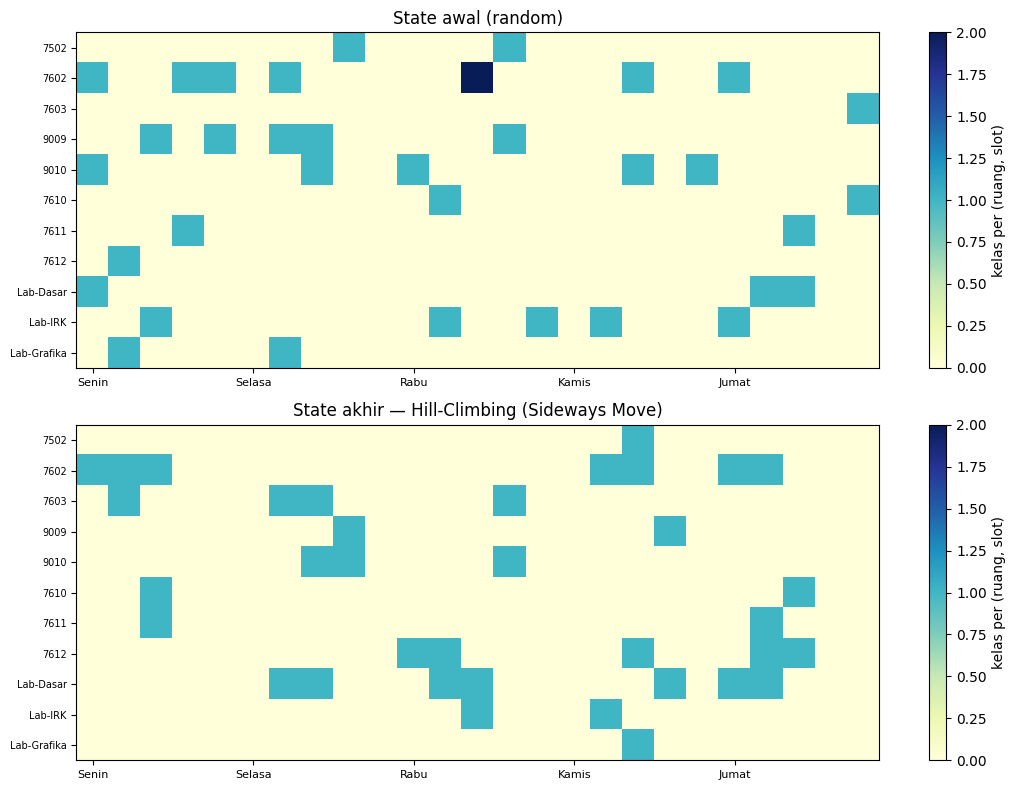

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))
for ax, (state, judul) in zip(axes, [(initial, "State awal (random)"),
                                     (best.final_state, f"State akhir — {best.name}")]):
    occ = np.zeros((problem.n_rooms, problem.n_slots))
    for t, r in state:
        occ[r, t] += 1
    im = ax.imshow(occ, aspect="auto", cmap="YlGnBu", vmin=0, vmax=2)
    ax.set_yticks(range(problem.n_rooms))
    ax.set_yticklabels([r.name for r in problem.rooms], fontsize=7)
    ax.set_xticks(range(0, problem.n_slots, 5))
    ax.set_xticklabels(["Senin", "Selasa", "Rabu", "Kamis", "Jumat"], fontsize=8)
    ax.set_title(judul); ax.grid(False)
    fig.colorbar(im, ax=ax, label="kelas per (ruang, slot)")
fig.tight_layout(); plt.show()

## 10. Kesimpulan

* **Hill-Climbing Steepest-Ascent** turun sangat cepat (puluhan iterasi) namun berhenti
  di local optimum; ia juga paling mahal per iterasi karena harus mengevaluasi seluruh
  1.854 tetangga.
* **Sideways Move** menembus plateau dan konsisten memperbaiki hasil Steepest-Ascent
  dengan biaya kira-kira dua kali lipat.
* **Stochastic HC** paling murah per iterasi tetapi rasio penerimaannya sangat rendah
  (< 1%), sehingga pada anggaran iterasi yang sama hasilnya paling buruk dan sering
  belum feasible.
* **Random Restart** memberi jaminan probabilistik terbaik untuk varian HC, dengan
  biaya evaluasi terbesar di antara semua algoritma.
* **Simulated Annealing** memberi hasil setara Random Restart dengan evaluasi f(X)
  sekitar sepuluh kali lebih sedikit — algoritma paling efisien pada persoalan ini.
* **Genetic Algorithm** turun paling cepat di awal tetapi mendatar lebih dini; crossover
  seragam pada representasi ini sering merusak kombinasi slot-ruang yang sudah baik.